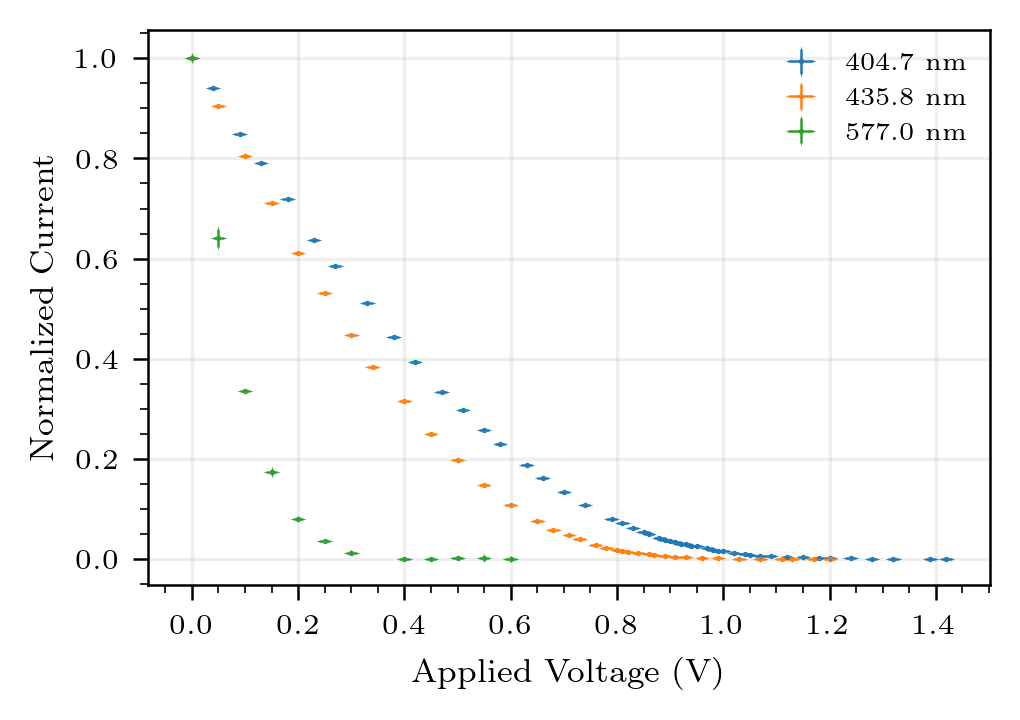

In [12]:
import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import warnings
from scipy.interpolate import UnivariateSpline
from scipy.optimize import brentq
with warnings.catch_warnings():
    warnings.simplefilter("ignore", DeprecationWarning)
    from scipy.odr import ODR, Model, RealData

plt.style.use("./jlab.mplstyle")

k        = 5
smoothing = 10000000
c        = 299792458   # m/s
wave_unc = 2           # nm
v_unc    = 0.01        # V
e        = 1.602e-19   # C

wavelengths = np.array([404.7, 435.8, 577.0])
wave = '577.0-old'
colors      = plt.rcParams["axes.prop_cycle"].by_key()["color"]
wl_colors   = {wl: colors[i] for i, wl in enumerate(wavelengths)}
frequencies = c / (wavelengths * 1e-9)
freq_unc    = (c / (wavelengths * 1e-9)**2) * wave_unc * 1e-9

def load_iv_data(wl_nm):
    if(wl_nm == 577.0):
        df = pd.read_csv(f"{wave}.csv")
    else:
        df = pd.read_csv(f"{wl_nm}.csv")
    I  = df[["I1", "I2", "I3", "I4", "I5"]].values
    return df["V"].values, I.mean(axis=1), scipy.stats.sem(I, axis=1)

datasets = {}
for wl in wavelengths:
    V, I, u = load_iv_data(wl)
    datasets[wl] = V, (I - I.min()) / (I.max()-I.min()), u / (I.max()-I.min())
    # datasets[wl] = V, I, u

fig, ax = plt.subplots(figsize=(3.5, 2.5))
for wl, (V, I, u) in datasets.items():
    ax.errorbar(V, I, yerr=u, xerr=np.ones_like(u)*v_unc, fmt="o", capsize=0.1, markersize=0.3,
                color=wl_colors[wl], label=f"{wl} nm")
ax.set_xlabel("Applied Voltage (V)")
ax.set_ylabel("Normalized Current")
ax.legend()
plt.tight_layout()
plt.grid(alpha=0.2)
plt.show()


In [13]:
def fit_spline(V, I, u, k_deg=None):
    """Fit a weighted UnivariateSpline and return the spline, its 2nd derivative, and a fine voltage grid."""
    k_use  = k_deg if k_deg is not None else k
    w      = np.where(u > 0, 1 / u, 1.0)
    us     = UnivariateSpline(V, I, w=w, k=k_use, s=smoothing)
    d2     = us.derivative().derivative()
    v_fine = np.linspace(V[0], V[-1], 500)
    return us, d2, v_fine

def find_vstop(d2, V, frac=0.4):
    """Find the leftmost zero-crossing of d2 in the upper (1-frac) fraction of the voltage range."""
    v_lo     = V[0] + frac * (V[-1] - V[0])
    v_search = np.linspace(v_lo, V[-1], 2000)
    idx      = np.where(np.diff(np.sign(d2(v_search))))[0]
    return brentq(d2, v_search[idx[0]], v_search[idx[0] + 1]) if idx.size > 0 else np.nan

def bootstrap_vstop(V, I, u, N=100, k_deg=None):
    """
    Estimate V_stop uncertainty by resampling data points with Gaussian noise.
    V noise: std = v_unc (voltage instrument uncertainty)
    I noise: std = u (per-point current SEM)
    Returns (mean, std) of V_stop across N trials, plus list of precomputed sample tuples.
    """
    samples = []
    vstops  = []
    for _ in range(N):
        V_boot = V + np.random.normal(0, v_unc, size=V.shape)
        I_boot = I + np.random.normal(0, u,     size=I.shape)
        order  = np.argsort(V_boot)
        V_b, I_b, u_b = V_boot[order], I_boot[order], u[order]
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                us_b, d2_b, v_b = fit_spline(V_b, I_b, u_b, k_deg=k_deg)
            vstop_b = find_vstop(d2_b, V_b)
            if np.isfinite(vstop_b):
                samples.append((v_b, us_b(v_b), d2_b(v_b), vstop_b))
                vstops.append(vstop_b)
        except Exception:
            pass
    return np.mean(vstops), np.std(vstops), samples


In [14]:
N = 1000

# --- Primary bootstrap: k=4 ---
boot_results = {}
boot_samples = {}
V_stops      = []
V_stops_unc  = []

for wl, (V, I, u) in datasets.items():
    mean, unc, samples = bootstrap_vstop(V, I, u, N=N, k_deg=4)
    boot_results[wl] = (mean, unc)
    boot_samples[wl] = samples
    V_stops.append(mean)
    V_stops_unc.append(unc)

V_stops     = np.array(V_stops)
V_stops_unc = np.array(V_stops_unc)

# --- Comparison bootstrap: k=5 ---
boot_results_k5 = {}

for wl, (V, I, u) in datasets.items():
    mean, unc, _ = bootstrap_vstop(V, I, u, N=N, k_deg=5)
    boot_results_k5[wl] = (mean, unc)

# --- Comparison table ---
print(f"{'λ (nm)':>8}  {'k=4: V_s (V)':>18}  {'k=5: V_s (V)':>18}  {'Δ (V)':>8}")
print("-" * 60)
for wl in wavelengths:
    m4, u4 = boot_results[wl]
    m5, u5 = boot_results_k5[wl]
    print(f"{wl:>8.1f}  {m4:.4f} ± {u4:.4f}   {m5:.4f} ± {u5:.4f}   {m5-m4:+.4f}")


  λ (nm)        k=4: V_s (V)        k=5: V_s (V)     Δ (V)
------------------------------------------------------------
   404.7  1.2561 ± 0.0087   1.2602 ± 0.0116   +0.0042
   435.8  1.0245 ± 0.0166   1.0317 ± 0.0211   +0.0072
   577.0  0.4049 ± 0.0193   0.4655 ± 0.0542   +0.0607


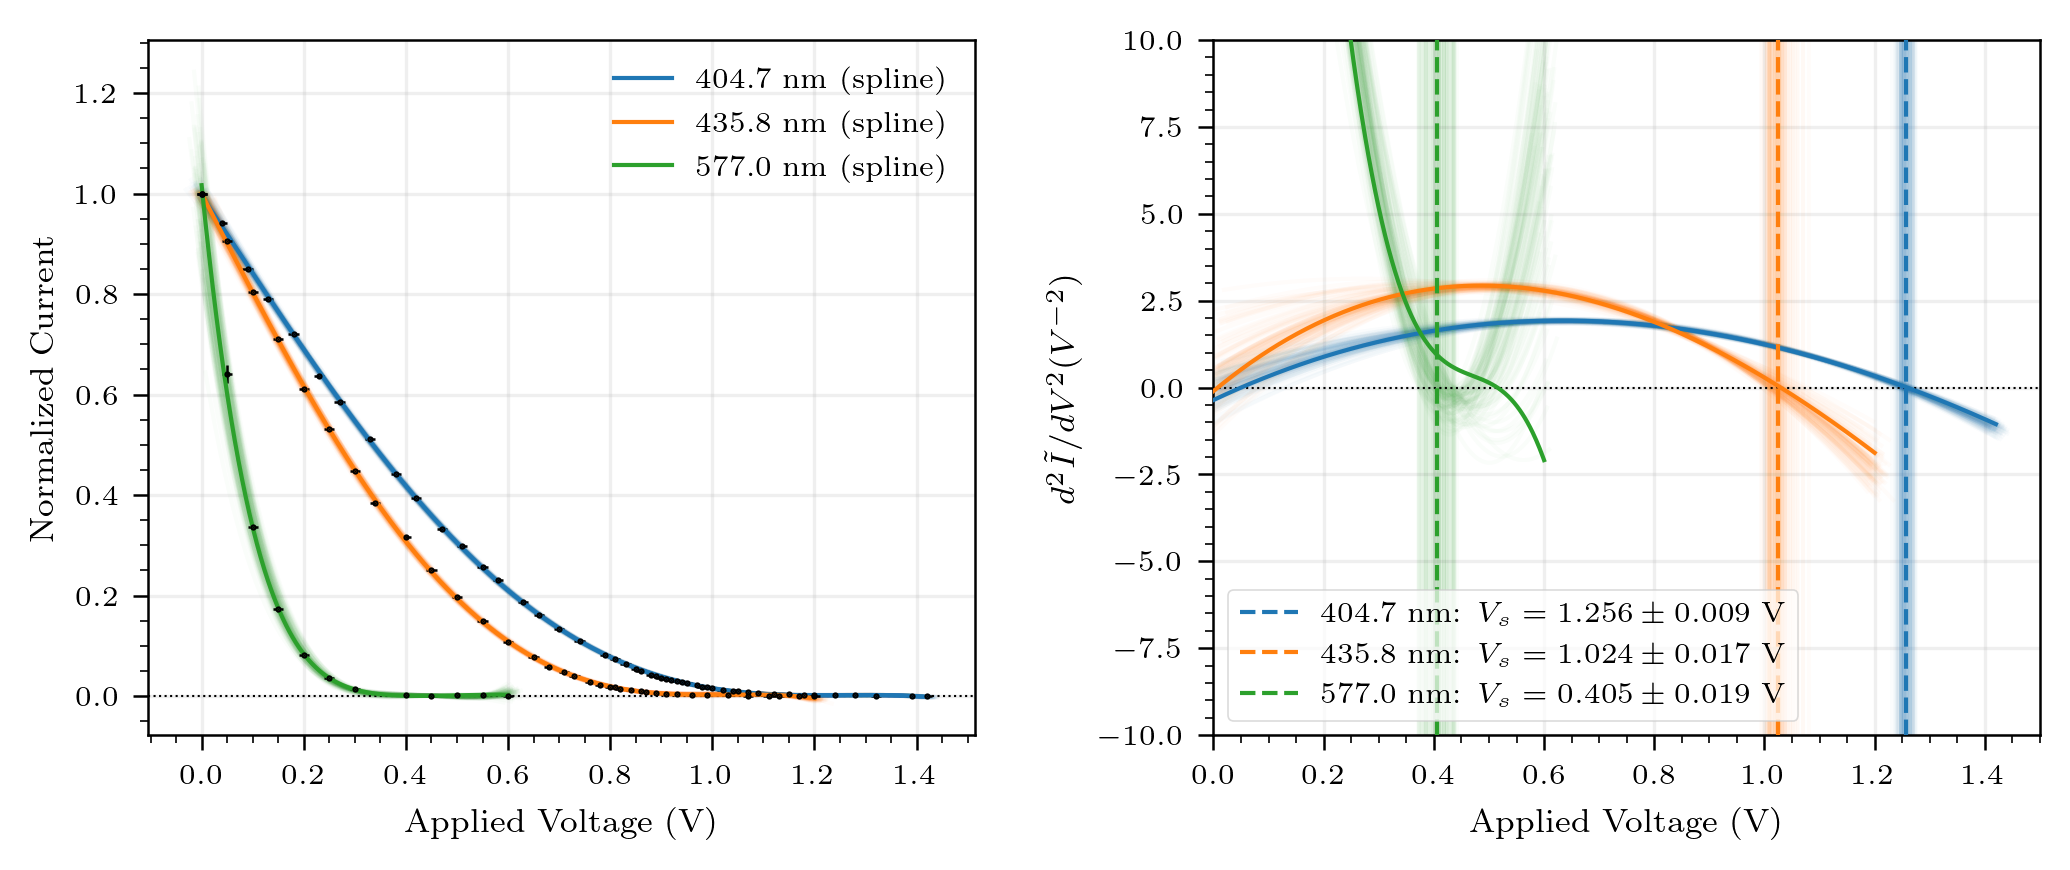

In [15]:
# --- settings ---
n_show      = 100
lw_main     = 1.0
lw_resample = 1.0
alpha_iv    = 0.02
alpha_d2    = 0.02
alpha_vstop = 0.02

fig, (ax_iv, ax_d2) = plt.subplots(1, 2, figsize=(7, 3))

for wl, (V, I, u) in datasets.items():
    color = wl_colors[wl]
    us_main, d2_main, v_fine = fit_spline(V, I, u)
    boot_mean, boot_unc = boot_results[wl]
    samples = boot_samples[wl]

    # raw data
    ax_iv.errorbar(V, I, yerr=u, xerr=v_unc, fmt="o", markersize=0.5, capsize=0, color="black", zorder=3)
    # main spline
    ax_iv.plot(v_fine, us_main(v_fine), color=color, linewidth=lw_main, label=f"{wl} nm (spline)", zorder=3)
    # main d²
    ax_d2.plot(v_fine, d2_main(v_fine), color=color, linewidth=lw_main, zorder=3)
    # mean V_stop line
    ax_d2.axvline(boot_mean, color=color, linewidth=lw_main, linestyle="--", zorder=3,
                  label=rf"{wl:.1f} nm: $V_s = {boot_mean:.3f} \pm {boot_unc:.3f}$ V")
    # resampled trajectories (k=4 only, from precomputed boot_samples)
    for v_b, spline_vals, d2_vals, vstop_b in samples[:n_show]:
        ax_iv.plot(v_b, spline_vals, color=color, linewidth=lw_resample, alpha=alpha_iv)
        ax_d2.plot(v_b, d2_vals,    color=color, linewidth=lw_resample, alpha=alpha_d2)
        ax_d2.axvline(vstop_b,      color=color, linewidth=lw_resample, alpha=alpha_vstop)

#horizontal line for ax_iv
ax_iv.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax_iv.grid(alpha=0.2)
ax_iv.set_xlabel("Applied Voltage (V)")
ax_iv.set_ylabel("Normalized Current")
ax_iv.legend(fontsize=7)

ax_d2.grid(alpha=0.2)
ax_d2.axhline(0, color="k", linewidth=0.5, linestyle=":")
ax_d2.set_xlim(0.0, 1.5)
ax_d2.set_ylim(-10, 10)
ax_d2.set_xlabel("Applied Voltage (V)")
ax_d2.set_ylabel(r"$d^2 \tilde{I}/dV^2 (V^{-2})$")
ax_d2.legend(fontsize=7, framealpha=0.7, frameon=True)

fig.tight_layout()
plt.show()

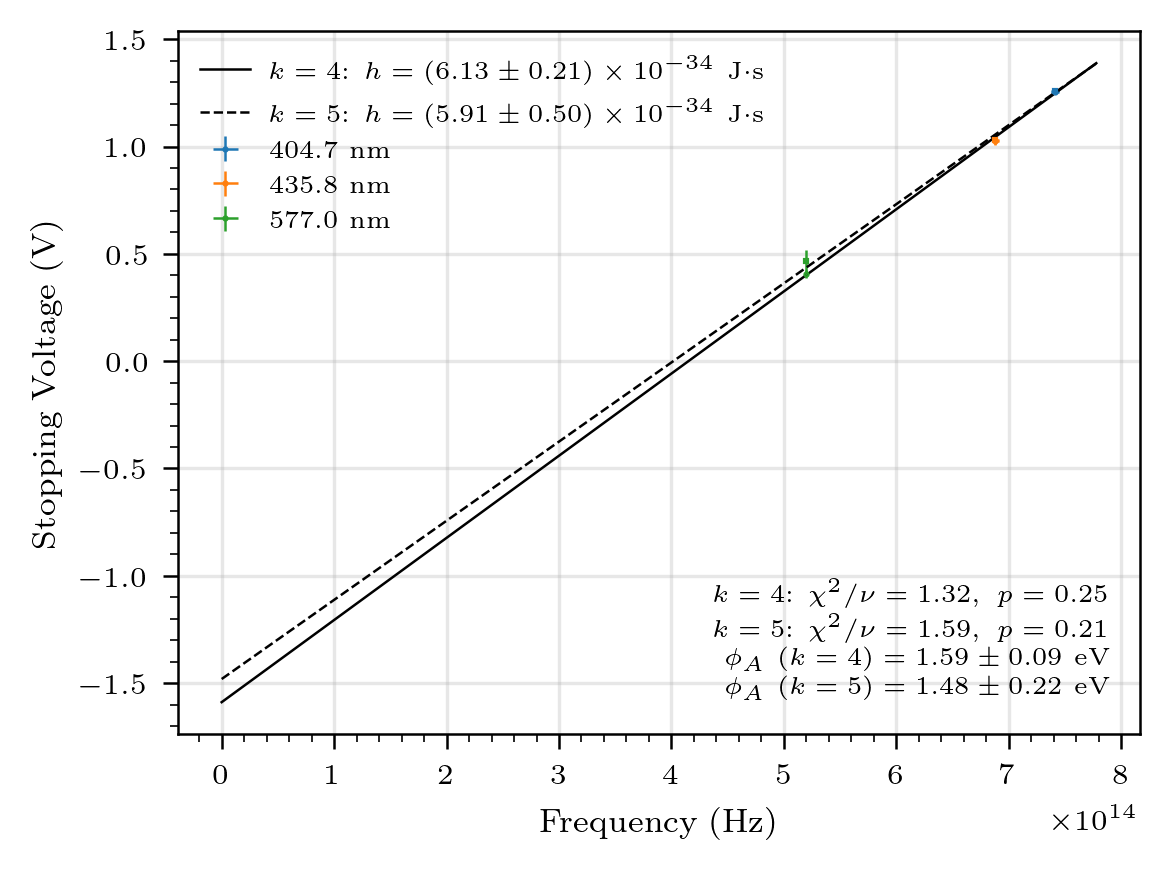

                        Planck's constant  h                        
  Model       h  (×10⁻³⁴ J·s)                 χ²/ν       p
--------------------------------------------------------------------
  k=4         6.132 ± 0.215 (stat)           1.318   0.251
  k=5         5.907 ± 0.499 (stat)           1.592   0.207
  Combined    6.097 ± 0.197 (stat) ± 0.112 (sys)
  True        6.626
  Discrepancy  2.33 σ

                         Work function  φ_A                         
  Model       φ_A  (eV)
--------------------------------------------------------------------
  k=4         1.589 ± 0.090 (stat)
  k=5         1.481 ± 0.222 (stat)
  Combined    1.574 ± 0.083 (stat)  +0.054 / -0.074 (sys)


In [16]:
markersize = 0.5
capsize = 0.0
precision = 2

def linear_odr(beta, x):
    return beta[0] * x + beta[1]

def run_odr(V_s, V_s_unc):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", DeprecationWarning)
        data   = RealData(frequencies, V_s, sx=freq_unc, sy=V_s_unc)
        result = ODR(data, Model(linear_odr), beta0=[3.8e-15, -1.0]).run()
    return result.beta, result.sd_beta, result.sum_square

V_stops_k5     = np.array([boot_results_k5[wl][0] for wl in wavelengths])
V_stops_unc_k5 = np.array([boot_results_k5[wl][1] for wl in wavelengths])

nu = len(frequencies) - 2   # degrees of freedom: n_points - n_params

(m4, b4), (m4_err, b4_err), chi2_4 = run_odr(V_stops,    V_stops_unc)
(m5, b5), (m5_err, b5_err), chi2_5 = run_odr(V_stops_k5, V_stops_unc_k5)

chi2_red_4, p4 = chi2_4 / nu, scipy.stats.chi2.sf(chi2_4, df=nu)
chi2_red_5, p5 = chi2_5 / nu, scipy.stats.chi2.sf(chi2_5, df=nu)

h4,   h4_err   = e * m4,  e * m4_err
h5,   h5_err   = e * m5,  e * m5_err
phi4, phi4_err = -b4, b4_err
phi5, phi5_err = -b5, b5_err

# --- Combined h ---
h_values        = np.array([h4, h5])
h_errors        = np.array([h4_err, h5_err])
h_weights       = 1 / h_errors**2
h_combined      = np.sum(h_weights * h_values) / np.sum(h_weights)
h_sigma_stat    = np.sqrt(1 / np.sum(h_weights))
h_model_unc     = np.abs(np.diff(h_values)[0]) / 2
h_total_unc     = np.sqrt(h_sigma_stat**2 + h_model_unc**2)
h_true          = 6.626e-34
error_from_true = np.abs(h_combined - h_true) / h_total_unc

# --- Combined phi (asymmetric systematic: thermal + model) ---
phi_values      = np.array([phi4, phi5])
phi_errors      = np.array([phi4_err, phi5_err])
phi_weights     = 1 / phi_errors**2
phi_combined    = np.sum(phi_weights * phi_values) / np.sum(phi_weights)
phi_sigma_stat  = np.sqrt(1 / np.sum(phi_weights))
phi_model_unc   = np.abs(np.diff(phi_values)[0]) / 2
thermal_unc     = 0.05  # eV — 4k_BT/2 ~ 2k_BT at room temperature
phi_sys_upper   = phi_model_unc
phi_sys_lower   = np.sqrt(phi_model_unc**2 + thermal_unc**2)

# --- Plot ---
f_fit = np.linspace(0, frequencies.max() * 1.05, 200)

fig, ax = plt.subplots(figsize=(4, 3))

for wl, f, f_u in zip(wavelengths, frequencies, freq_unc):
    m4_i, u4_i = boot_results[wl]
    m5_i, u5_i = boot_results_k5[wl]
    color = wl_colors[wl]
    ax.errorbar(f, m4_i, yerr=u4_i, xerr=f_u, fmt="o", markersize=markersize, capsize=capsize, color=color, label=f"{wl} nm")
    ax.errorbar(f, m5_i, yerr=u5_i, xerr=f_u, fmt="s", markersize=markersize, capsize=capsize, color=color)

ax.plot(f_fit, m4 * f_fit + b4, color="k", linestyle="-",
        label=rf"$k=4$: $h = ({h4/1e-34:.{precision}f} \pm {h4_err/1e-34:.{precision}f}) \times 10^{{-34}}$ J·s")
ax.plot(f_fit, m5 * f_fit + b5, color="k", linestyle="--",
        label=rf"$k=5$: $h = ({h5/1e-34:.{precision}f} \pm {h5_err/1e-34:.{precision}f}) \times 10^{{-34}}$ J·s")

stats_text = (
    rf"$k=4$: $\chi^2/\nu={chi2_red_4:.{precision}f},\ p={p4:.{precision}f}$" + "\n" +
    rf"$k=5$: $\chi^2/\nu={chi2_red_5:.{precision}f},\ p={p5:.{precision}f}$" + "\n" +
    rf"$\phi_A\ (k=4) = {phi4:.{precision}f} \pm {phi4_err:.{precision}f}$ eV" + "\n" +
    rf"$\phi_A\ (k=5) = {phi5:.{precision}f} \pm {phi5_err:.{precision}f}$ eV"
)
ax.text(0.97, 0.05, stats_text, transform=ax.transAxes,
        ha="right", va="bottom", fontsize=6)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Stopping Voltage (V)")
ax.legend(fontsize=6)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# --- Results table ---
W = 68
print("=" * W)
print(f"{'Planck\'s constant  h':^{W}}")
print("=" * W)
print(f"  {'Model':<10}  {'h  (×10⁻³⁴ J·s)':<28}  {'χ²/ν':>6}  {'p':>6}")
print("-" * W)
print(f"  {'k=4':<10}  {h4/1e-34:.3f} ± {h4_err/1e-34:.3f} (stat)          {chi2_red_4:>6.3f}  {p4:>6.3f}")
print(f"  {'k=5':<10}  {h5/1e-34:.3f} ± {h5_err/1e-34:.3f} (stat)          {chi2_red_5:>6.3f}  {p5:>6.3f}")
print(f"  {'Combined':<10}  {h_combined/1e-34:.3f} ± {h_sigma_stat/1e-34:.3f} (stat) ± {h_model_unc/1e-34:.3f} (sys)")
print(f"  {'True':<10}  6.626")
print(f"  {'Discrepancy':<10}  {error_from_true:.2f} σ")
print()
print("=" * W)
print(f"{'Work function  φ_A':^{W}}")
print("=" * W)
print(f"  {'Model':<10}  {'φ_A  (eV)'}")
print("-" * W)
print(f"  {'k=4':<10}  {phi4:.3f} ± {phi4_err:.3f} (stat)")
print(f"  {'k=5':<10}  {phi5:.3f} ± {phi5_err:.3f} (stat)")
print(f"  {'Combined':<10}  {phi_combined:.3f} ± {phi_sigma_stat:.3f} (stat)  +{phi_sys_upper:.3f} / -{phi_sys_lower:.3f} (sys)")
print("=" * W)


577.0-tape:  V_s = 0.3645 ± 0.0253 V
577.0:       V_s = 0.4049  ± 0.0193  V

With 577.0-tape (k=4):
  h   = (6.447 ± 0.164) × 10⁻³⁴ J·s
  φ_A = (1.731 ± 0.070) eV


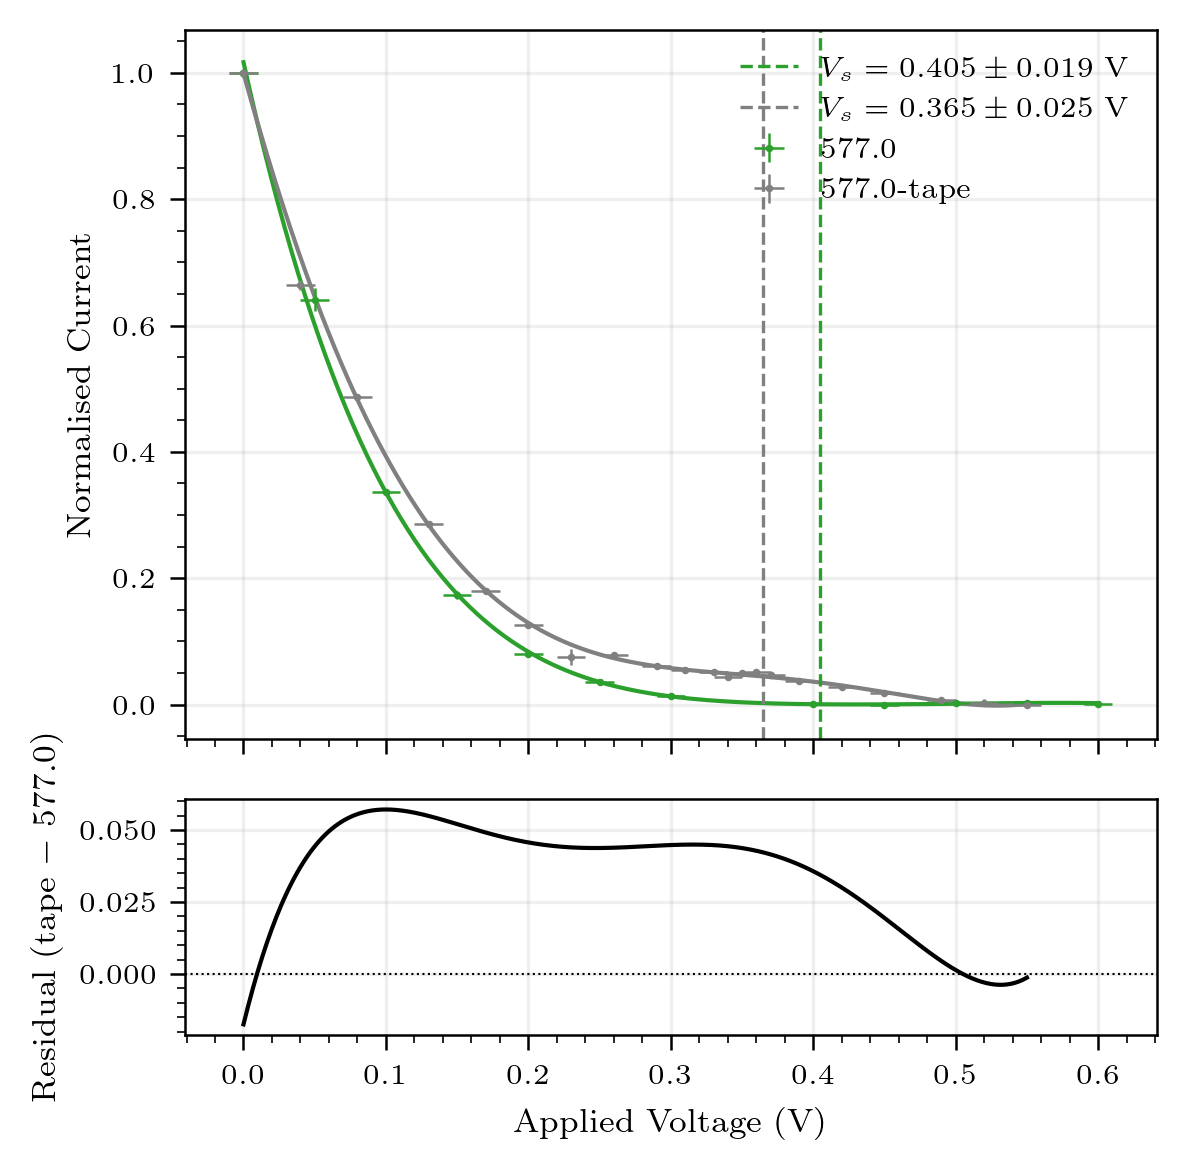

In [17]:
# --- Load 577.0-tape data ---
df_tape     = pd.read_csv("577.0-tape.csv")
V_tape      = df_tape["V"].values
I_tape_raw  = df_tape[["I1", "I2", "I3", "I4", "I5"]].values
I_tape_mean = I_tape_raw.mean(axis=1)
u_tape_raw  = scipy.stats.sem(I_tape_raw, axis=1)
I_norm_tape = (I_tape_mean - I_tape_mean.min()) / (I_tape_mean.max() - I_tape_mean.min())
u_norm_tape = u_tape_raw / (I_tape_mean.max() - I_tape_mean.min())

# --- 577.0 data from existing datasets (already normalised) ---
V_577, I_norm_577, u_norm_577 = datasets[577.0]

# --- Bootstrap tape data (577.0 results reused from boot_results) ---
vs_tape, vs_tape_unc, _ = bootstrap_vstop(V_tape, I_norm_tape, u_norm_tape, N=N, k_deg=4)
vs_577,  vs_577_unc     = boot_results[577.0]   # reuse precomputed

print(f"577.0-tape:  V_s = {vs_tape:.4f} ± {vs_tape_unc:.4f} V")
print(f"577.0:       V_s = {vs_577:.4f}  ± {vs_577_unc:.4f}  V")

# --- Splines for residual panel ---
us_tape, _, v_fine_tape = fit_spline(V_tape, I_norm_tape, u_norm_tape)
us_577,  _, v_fine_577  = fit_spline(V_577,  I_norm_577,  u_norm_577)

v_lo  = max(V_tape.min(), V_577.min())
v_hi  = min(V_tape.max(), V_577.max())
v_res = np.linspace(v_lo, v_hi, 500)
resid = us_tape(v_res) - us_577(v_res)

# --- Alternative ODR: swap 577.0 V_stop for tape V_stop ---
V_stops_tape     = V_stops.copy()
V_stops_unc_tape = V_stops_unc.copy()
V_stops_tape[2]     = vs_tape
V_stops_unc_tape[2] = vs_tape_unc

(m_t, b_t), (m_t_err, b_t_err), _ = run_odr(V_stops_tape, V_stops_unc_tape)
h_tape,   h_tape_err   = e * m_t,  e * m_t_err
phi_tape, phi_tape_err = -b_t, b_t_err

print()
print(f"With 577.0-tape (k=4):")
print(f"  h   = ({h_tape/1e-34:.3f} ± {h_tape_err/1e-34:.3f}) × 10⁻³⁴ J·s")
print(f"  φ_A = ({phi_tape:.3f} ± {phi_tape_err:.3f}) eV")

# --- Plot: top = I-V curves, bottom = residual ---
color_577  = wl_colors[577.0]
color_tape = "gray"

fig, (ax_top, ax_res) = plt.subplots(2, 1, figsize=(4, 4), sharex=True,
                                      gridspec_kw={"height_ratios": [3, 1]})

ax_top.errorbar(V_577,  I_norm_577,  yerr=u_norm_577,  xerr=v_unc, fmt="o", markersize=0.8,
                capsize=0, color=color_577,  zorder=3, label="577.0")
ax_top.errorbar(V_tape, I_norm_tape, yerr=u_norm_tape, xerr=v_unc, fmt="o", markersize=0.8,
                capsize=0, color=color_tape, zorder=3, label="577.0-tape")
ax_top.plot(v_fine_577,  us_577(v_fine_577),  color=color_577,  lw=1)
ax_top.plot(v_fine_tape, us_tape(v_fine_tape), color=color_tape, lw=1)
ax_top.axvline(vs_577,  color=color_577,  lw=0.8, linestyle="--",
               label=rf"$V_s = {vs_577:.3f} \pm {vs_577_unc:.3f}$ V")
ax_top.axvline(vs_tape, color=color_tape, lw=0.8, linestyle="--",
               label=rf"$V_s = {vs_tape:.3f} \pm {vs_tape_unc:.3f}$ V")
ax_top.set_ylabel("Normalised Current")
ax_top.legend(fontsize=7, framealpha=0.7)
ax_top.grid(alpha=0.2)

ax_res.plot(v_res, resid, color="k", lw=1)
ax_res.axhline(0, color="k", lw=0.5, linestyle=":")
ax_res.set_ylabel("Residual (tape − 577.0)")
ax_res.set_xlabel("Applied Voltage (V)")
ax_res.grid(alpha=0.2)

fig.tight_layout()
plt.show()


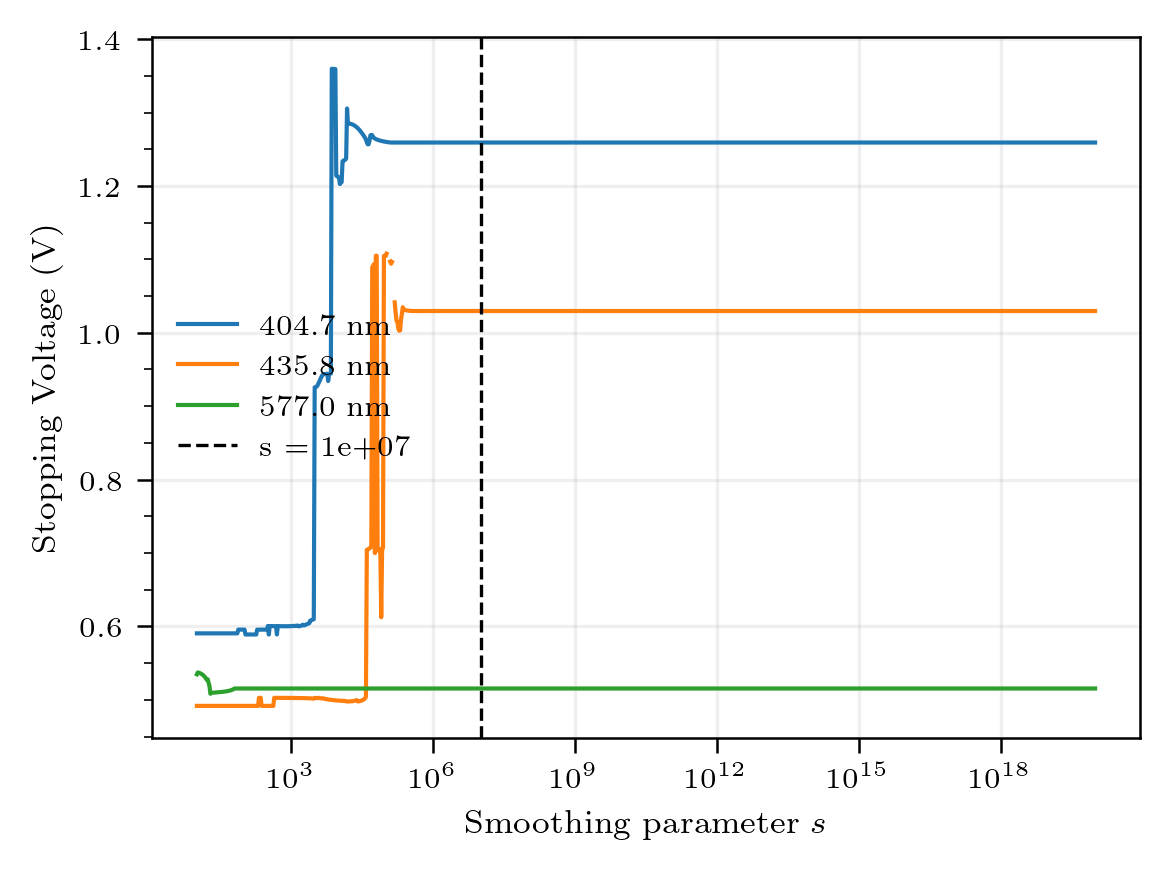

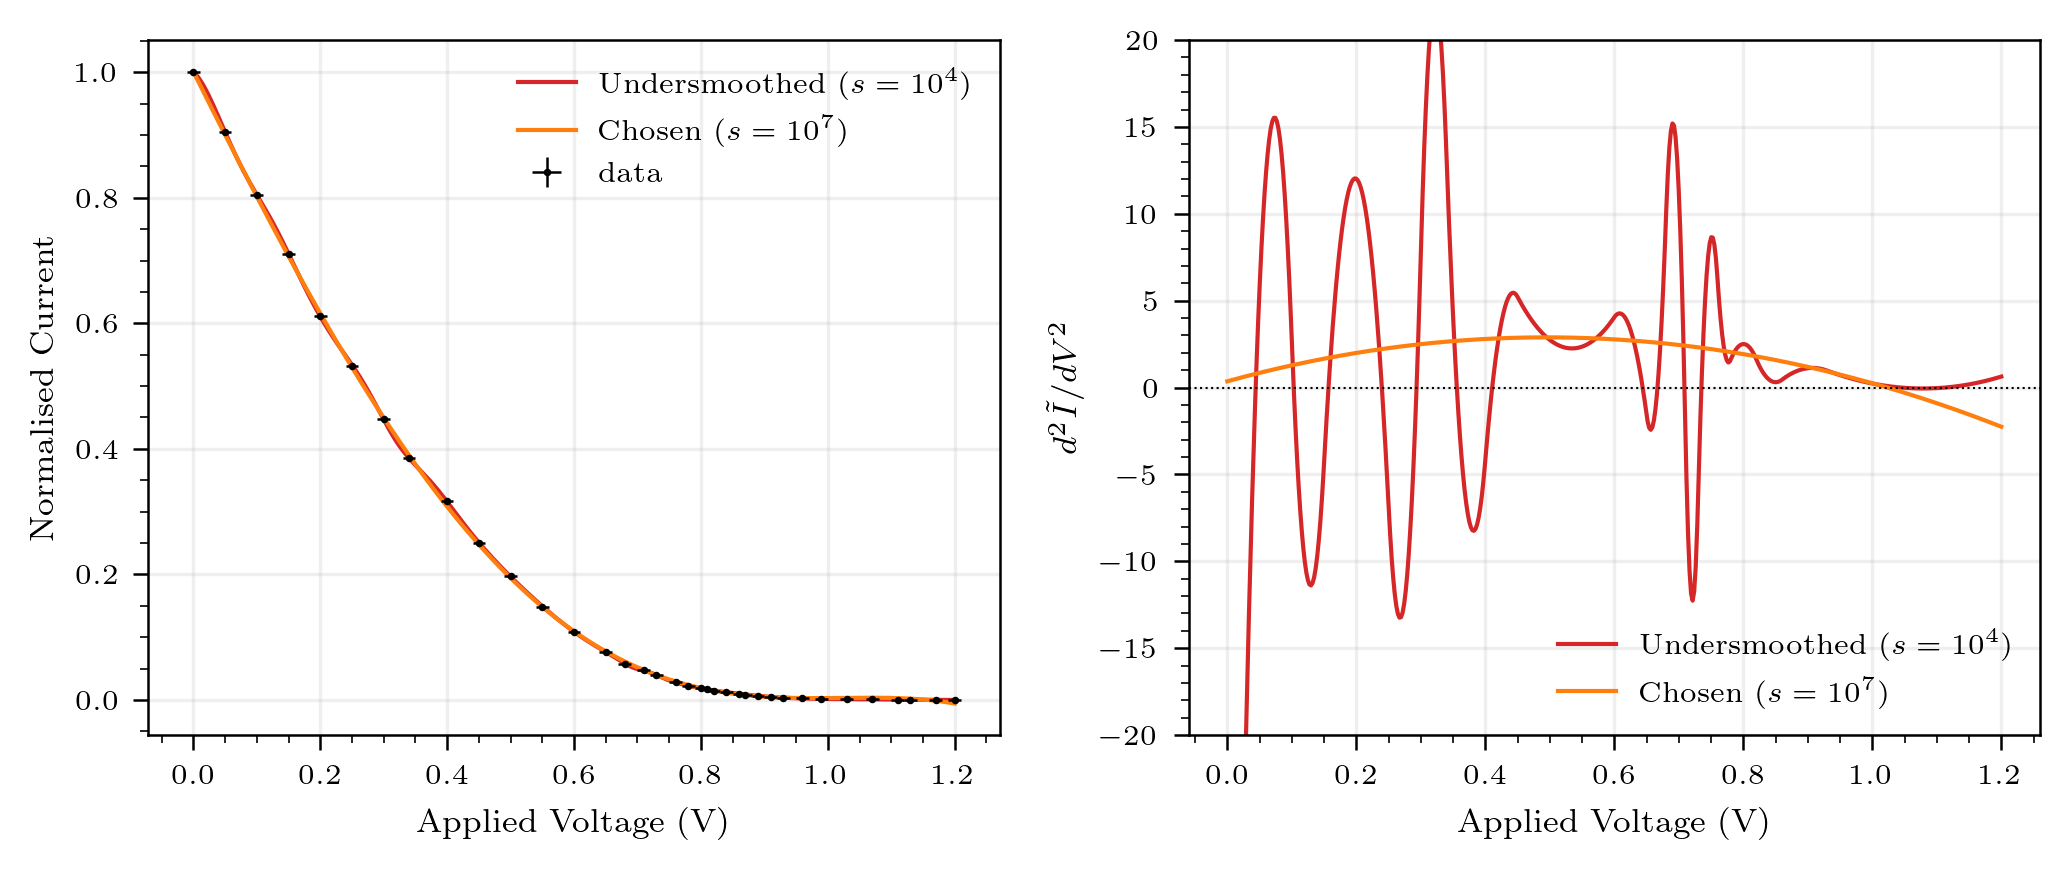

In [18]:
s_values = np.logspace(1, 20, 1000)

fig, ax = plt.subplots(figsize=(4, 3))

for wl, (V, I, u) in datasets.items():
    color  = wl_colors[wl]
    vstops = []
    for s in s_values:
        try:
            w  = np.where(u > 0, 1 / u, 1.0)
            us = UnivariateSpline(V, I, w=w, k=5, s=s)
            d2 = us.derivative().derivative()
            vs = find_vstop(d2, V)
            vstops.append(vs if np.isfinite(vs) else np.nan)
        except Exception:
            vstops.append(np.nan)
    ax.plot(s_values, vstops, color=color, lw=1, label=f"{wl} nm")

ax.axvline(smoothing, color="k", lw=0.8, linestyle="--", label=f"s = {smoothing:.0e}")
ax.set_xscale("log")
ax.set_xlabel("Smoothing parameter $s$")
ax.set_ylabel("Stopping Voltage (V)")
ax.legend(fontsize=7)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

# --- Spline comparison: low s (overfit) vs chosen s ---
s_low  = 10e3
wl_eg  = 435.8   # representative wavelength
V, I, u = datasets[wl_eg]
w = np.where(u > 0, 1 / u, 1.0)

us_low  = UnivariateSpline(V, I, w=w, k=4, s=s_low)
us_good = UnivariateSpline(V, I, w=w, k=4, s=smoothing)
d2_low  = us_low.derivative().derivative()
d2_good = us_good.derivative().derivative()
v_fine  = np.linspace(V[0], V[-1], 500)

label_low  = f"Undersmoothed ($s = 10^{{{int(np.log10(s_low))}}}$)"
label_good = f"Chosen ($s = 10^{{{int(np.log10(smoothing))}}}$)"

fig, (ax_iv, ax_d2) = plt.subplots(1, 2, figsize=(7, 3))

ax_iv.errorbar(V, I, yerr=u, xerr=v_unc, fmt="o", markersize=0.8, capsize=0,
               color="black", zorder=3, label="data")
ax_iv.plot(v_fine, us_low(v_fine),  color="tab:red",        lw=1, label=label_low)
ax_iv.plot(v_fine, us_good(v_fine), color=wl_colors[wl_eg], lw=1, label=label_good)
ax_iv.set_xlabel("Applied Voltage (V)")
ax_iv.set_ylabel("Normalised Current")
ax_iv.legend(fontsize=7)
ax_iv.grid(alpha=0.2)

ax_d2.plot(v_fine, d2_low(v_fine),  color="tab:red",        lw=1, label=label_low)
ax_d2.plot(v_fine, d2_good(v_fine), color=wl_colors[wl_eg], lw=1, label=label_good)
ax_d2.axhline(0, color="k", lw=0.5, linestyle=":")
ax_d2.set_xlabel("Applied Voltage (V)")
ax_d2.set_ylim(-20, 20)
ax_d2.set_ylabel(r"$d^2\tilde{I}/dV^2$")
ax_d2.legend(fontsize=7)
ax_d2.grid(alpha=0.2)

fig.tight_layout()
plt.show()


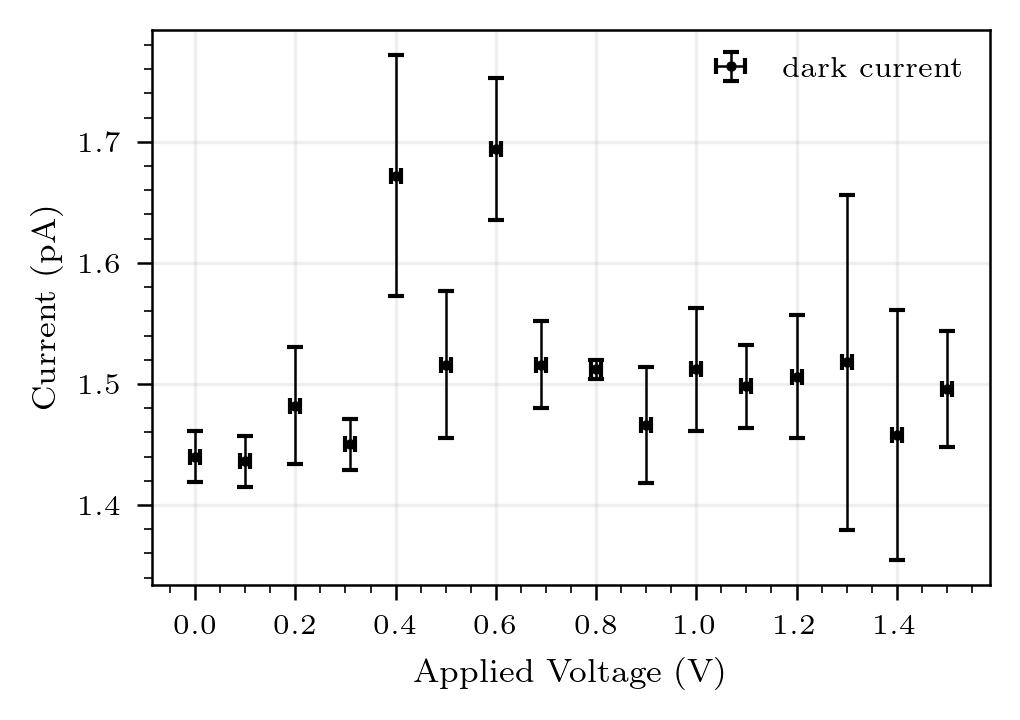

In [19]:
# --- Dark current ---
df_dark     = pd.read_csv("Dark Current.csv")
V_dark      = df_dark["V"].values
I_dark      = df_dark[["I1", "I2", "I3", "I4", "I5"]].values
I_dark_mean = I_dark.mean(axis=1) * 1e3   # mA
u_dark      = scipy.stats.sem(I_dark, axis=1) * 1e3

# --- Linear ODR fit ---
def linear_dark(beta, x):
    return beta[0] * x + beta[1]

with warnings.catch_warnings():
    warnings.simplefilter("ignore", DeprecationWarning)
    data_dark   = RealData(V_dark, I_dark_mean, sx=v_unc, sy=u_dark)
    result_dark = ODR(data_dark, Model(linear_dark),
                      beta0=[0.0, I_dark_mean.mean()]).run()

slope, intercept = result_dark.beta
slope_err        = result_dark.sd_beta[0]
nu_dark          = len(V_dark) - 2
chi2_dark        = result_dark.sum_square
chi2_red_dark    = chi2_dark / nu_dark
p_dark           = scipy.stats.chi2.sf(chi2_dark, df=nu_dark)

v_fit = np.linspace(V_dark.min(), V_dark.max(), 200)

fig, ax = plt.subplots(figsize=(3.5, 2.5))
ax.errorbar(V_dark, I_dark_mean, yerr=u_dark, xerr=v_unc,
            fmt="o", markersize=1.5, capsize=2, color="k", label="dark current")
# ax.plot(v_fit, slope * v_fit + intercept, color="tab:red", lw=1,
#         label=rf"fit: slope $= {slope:.4f} \pm {slope_err:.4f}$ mA/V")

# stats_text = rf"$\chi^2/\nu = {chi2_red_dark:.2f},\ p = {p_dark:.3f}$"
# ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
#         ha="right", va="top", fontsize=7,
#         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

ax.set_xlabel("Applied Voltage (V)")
ax.set_ylabel("Current (pA)")
ax.legend(fontsize=7)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

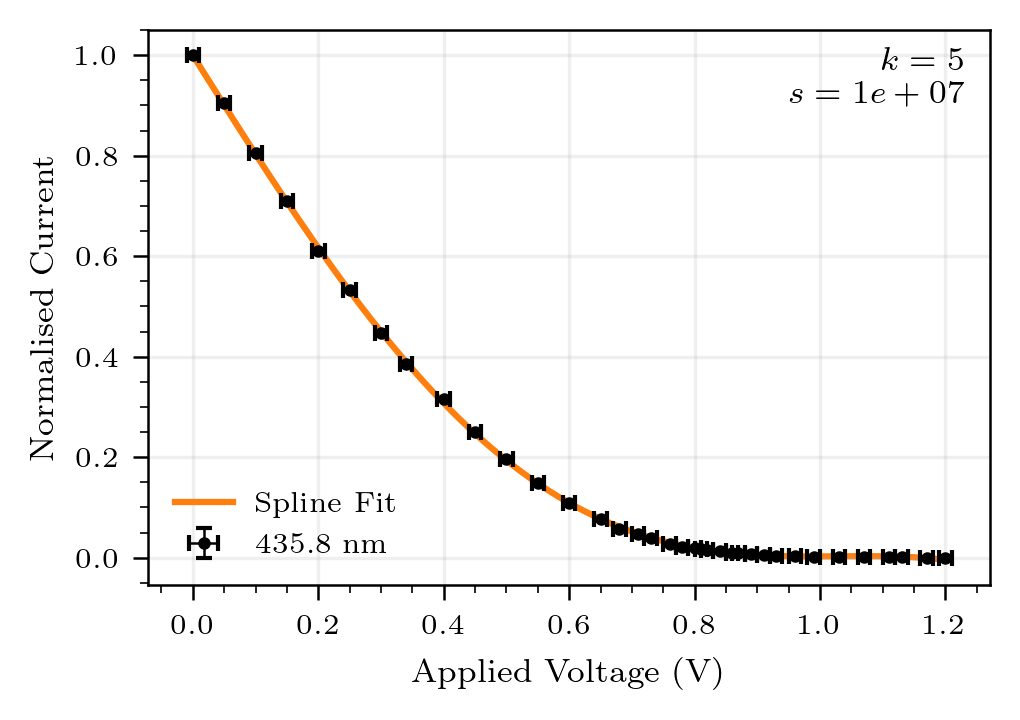

In [20]:
# --- Spline illustration: 435.8 nm ---
wl_ill      = 435.8
V_ill, I_ill, u_ill = datasets[wl_ill]
us_ill, _, v_ill    = fit_spline(V_ill, I_ill, u_ill)

fig, ax = plt.subplots(figsize=(3.5, 2.5))
ax.errorbar(V_ill, I_ill, yerr=u_ill, xerr=v_unc,
            fmt='o', markersize=2, capsize=2, color='k',
            label='435.8 nm', zorder=3)
ax.plot(v_ill, us_ill(v_ill), color=wl_colors[wl_ill], lw=1.5, label='Spline Fit',zorder=1)

ax.text(0.97, 0.97,
        rf'$k = {k}$' + '\n' + rf'$s = {smoothing:.0e}$',
        transform=ax.transAxes, ha='right', va='top', fontsize=8)
ax.set_xlabel('Applied Voltage (V)')
ax.set_ylabel('Normalised Current')
ax.legend(fontsize=7)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

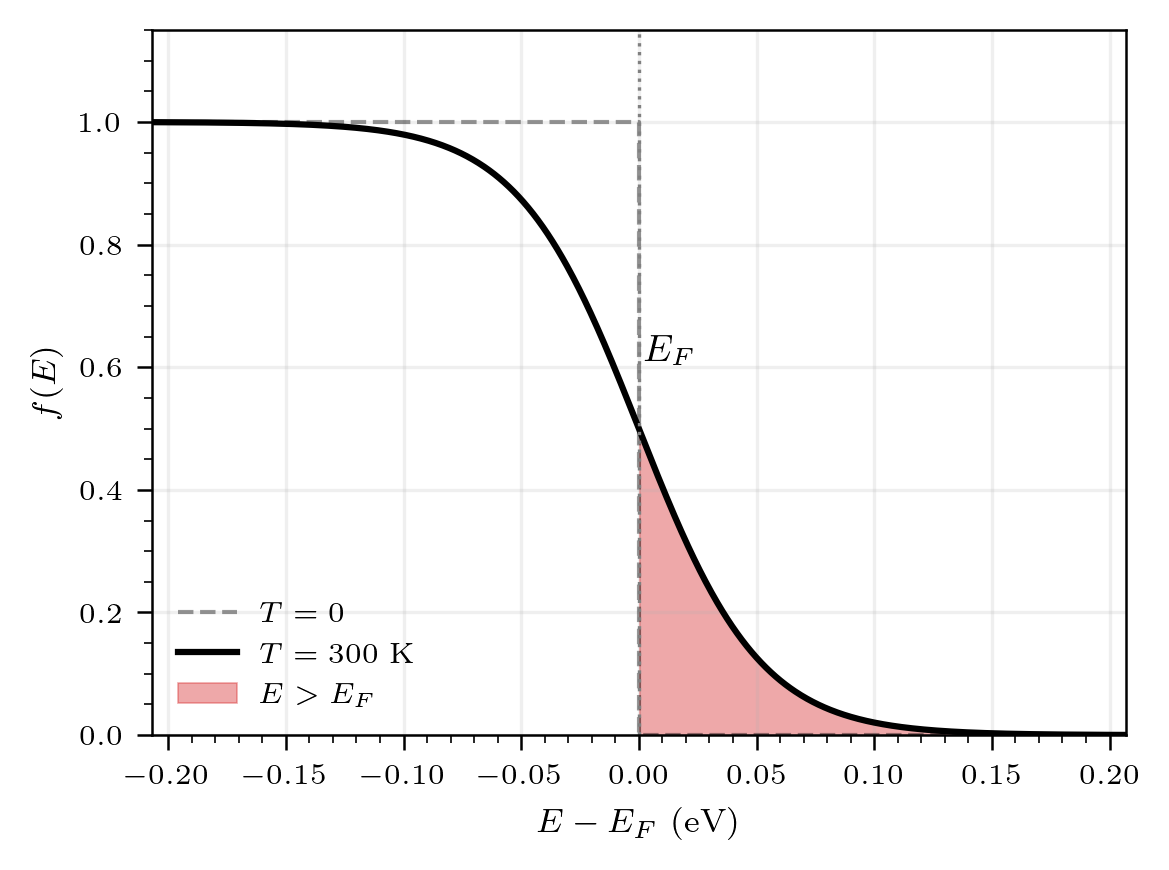

In [21]:
# --- Fermi-Dirac illustration ---
k_B   = 1.381e-23   # J/K
T_ill = 300          # K
kT    = k_B * T_ill / e   # eV

E = np.linspace(-8 * kT, 8 * kT, 1000)   # energy relative to E_F (eV)
f = 1 / (np.exp(E / kT) + 1)

fig, ax = plt.subplots(figsize=(4, 3))

# T = 0 step function
ax.step([E[0], 0, 0, E[-1]], [1, 1, 0, 0],
        color='k', lw=1, linestyle='--', alpha=0.4, label=r'$T = 0$', where='post')

# Finite-T curve
ax.plot(E, f, color='k', lw=1.5, label=rf'$T = {T_ill}$ K')

# Shade tail: E > E_F
ax.fill_between(E, f, where=(E >= 0),
                color='tab:red', alpha=0.4, label=r'$E > E_F$')

# E_F marker
ax.axvline(0, color='gray', lw=0.8, linestyle=':')
ax.text(0.002, 0.52, r'$E_F$', transform=ax.get_xaxis_transform(),
        ha='left', va='bottom', fontsize=9)

# # kT bracket
# ax.annotate('', xy=(kT, 0.07), xytext=(0, 0.07),
#             arrowprops=dict(arrowstyle='<->', color='tab:red', lw=1))
# ax.text(kT / 2, 0.12, r'$k_B T$', ha='center', va='bottom',
#         color='tab:red', fontsize=8)

ax.set_xlim(E[0], E[-1])
ax.set_ylim(0, 1.15)
ax.set_xlabel(r'$E - E_F$ (eV)')
ax.set_ylabel(r'$f(E)$')
ax.legend(fontsize=7, loc='lower left')
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()
